# 4.4 — Análise de Interações: S_Ti − S_i × Beeswarm SHAP

Quantifica a fração de interação de cada input a partir de `S_Ti − S_i` e cruza com os beeswarm plots SHAP da Etapa 3.

**Dependências:** `4.1_sobol_8inputs_resultados.csv`, beeswarms em `ARTEFATOS/ETAPA_3/shap/3.1/`.

## Seção 1 — Carga de dados

In [1]:
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from IPython.display import Image, display

In [ ]:
df_sobol = pd.read_csv('../4.1/4.1_sobol_8inputs_resultados.csv')

assert df_sobol.isnull().sum().sum() == 0, 'NaN encontrado em df_sobol'
assert set(df_sobol.columns) >= {'output', 'feature', 'S1', 'ST'}, 'Colunas esperadas ausentes'

print(f'df_sobol: {df_sobol.shape} linhas — sem NaN')
print(df_sobol.to_string(index=False))

## Seção 2 — Cálculo de S_Ti − S_i

In [3]:
LIMIAR  = 0.30
ST_MIN  = 0.02  # features com ST < ST_MIN têm importância desprezível; frac_interacao indefinida

df = df_sobol.copy()

# S1 negativo é artefato de amostragem (Sobol teórico ≥ 0); clampar antes de calcular interacao
df['S1_clamped'] = df['S1'].clip(lower=0)
df['interacao']  = (df['ST'] - df['S1_clamped']).clip(lower=0)

# frac_interacao definida apenas onde ST > ST_MIN; caso contrário NaN (importância insuficiente)
df['frac_interacao'] = np.where(
    df['ST'] > ST_MIN,
    (df['interacao'] / df['ST']).clip(0.0, 1.0),
    np.nan
)

# D-E4-07: ajustar limiar para 0.20 se nenhuma feature elegível atingir 0.30
elegivel = df[df['frac_interacao'].notna()]
if elegivel[elegivel['frac_interacao'] > LIMIAR].empty:
    LIMIAR = 0.20
    print(f'[D-E4-07] Nenhuma feature atingiu 0.30 — ajustando limiar para {LIMIAR}')
else:
    print(f'Limiar mantido em {LIMIAR}  |  ST_MIN = {ST_MIN}')

n_excluidas = df['frac_interacao'].isna().sum()
print(f'{n_excluidas} pares excluídos por ST < {ST_MIN} (importância desprezível)')
print(f'\nFeatures elegíveis com frac_interacao > {LIMIAR}:')
print(
    df[(df['frac_interacao'].notna()) & (df['frac_interacao'] > LIMIAR)][
        ['output', 'feature', 'S1', 'ST', 'interacao', 'frac_interacao']
    ].sort_values(['output', 'frac_interacao'], ascending=[True, False]).to_string(index=False)
)

Limiar mantido em 0.3  |  ST_MIN = 0.02
8 pares excluídos por ST < 0.02 (importância desprezível)

Features elegíveis com frac_interacao > 0.3:
 output feature        S1       ST  interacao  frac_interacao
     ET    RRC1 -0.001958 0.026518   0.026518        1.000000
     ET      T1  0.014545 0.086404   0.071860        0.831669
     ET    RRC2  0.088766 0.129563   0.040797        0.314883
M_CH3OH    RRC1  0.158321 0.239312   0.080991        0.338434
x_CH3OH      T1  0.003149 0.027847   0.024698        0.886934
x_CH3OH    BRC2  0.024955 0.089068   0.064113        0.719822
x_CH3OH    RRC2  0.036481 0.101439   0.064957        0.640362
x_CH3OH    BRC1  0.120505 0.324726   0.204221        0.628904
x_CH3OH    RRC1  0.522142 0.749615   0.227472        0.303452


In [4]:
# Validação: frac_interacao ∈ [0, 1] para todos os pares elegíveis (ST > ST_MIN)
elegivel = df[df['frac_interacao'].notna()]
assert (elegivel['frac_interacao'] >= 0).all(), 'frac_interacao negativa encontrada'
assert (elegivel['frac_interacao'] <= 1).all(), 'frac_interacao > 1 encontrada'
print(f'Validação OK: frac_interacao ∈ [0, 1] para {len(elegivel)} pares elegíveis')
print(f'Excluídos por ST < {ST_MIN}: {df["frac_interacao"].isna().sum()} pares')

Validação OK: frac_interacao ∈ [0, 1] para 16 pares elegíveis
Excluídos por ST < 0.02: 8 pares


## Seção 3 — Barplots de interação

In [5]:
OUTPUT_LABELS = {'ET': 'ET (kW)', 'M_CH3OH': 'M_CH3OH (kg/hr)', 'x_CH3OH': 'x_CH3OH'}
OUTPUT_FILES  = {
    'ET':      '4.4_interacoes_barplot_ET.png',
    'M_CH3OH': '4.4_interacoes_barplot_M.png',
    'x_CH3OH': '4.4_interacoes_barplot_x.png',
}
COR_NORMAL  = '#4C72B0'
COR_ALTA    = '#DD8452'
COR_BAIXA_ST = '#BBBBBB'  # ST < ST_MIN: importância insuficiente para análise de interação

for output in ['ET', 'M_CH3OH', 'x_CH3OH']:
    sub = df[df['output'] == output].copy()
    sub = sub.sort_values('ST', ascending=False)

    def cor_barra(row):
        if row['ST'] <= ST_MIN:
            return COR_BAIXA_ST
        return COR_ALTA if (row['frac_interacao'] > LIMIAR) else COR_NORMAL

    colors = [cor_barra(r) for _, r in sub.iterrows()]

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.barh(sub['feature'], sub['interacao'], color=colors, edgecolor='white', height=0.65)

    ax.set_xlabel('S_Ti - S_i (interacao)', fontsize=11)
    ax.set_title(f'Interacao Sobol — {OUTPUT_LABELS[output]}', fontsize=12)
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')

    patch_alta     = mpatches.Patch(color=COR_ALTA,     label=f'frac_interacao > {LIMIAR:.2f}')
    patch_normal   = mpatches.Patch(color=COR_NORMAL,   label=f'frac_interacao <= {LIMIAR:.2f}')
    patch_baixa_st = mpatches.Patch(color=COR_BAIXA_ST, label=f'ST <= {ST_MIN} (irrelevante)')
    ax.legend(handles=[patch_alta, patch_normal, patch_baixa_st], fontsize=9, loc='lower right')

    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig(OUTPUT_FILES[output], dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Salvo: {OUTPUT_FILES[output]}')

Salvo: 4.4_interacoes_barplot_ET.png
Salvo: 4.4_interacoes_barplot_M.png
Salvo: 4.4_interacoes_barplot_x.png


/var/folders/yp/4mc_b2c54g7fpgchq00gm31c0000gn/T/ipykernel_18608/3609893436.py:37: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## Seção 4 — Cruzamento com beeswarm SHAP

Para cada feature com interação alta (`frac_interacao > LIMIAR`): exibir beeswarm de ANN e XGBoost.

In [ ]:
BEESWARM_DIR   = Path('../../ETAPA_3/shap/3.1')
MODELOS_EXIBIR = ['ANN', 'XGBoost']

altas = (
    df[(df['frac_interacao'].notna()) & (df['frac_interacao'] > LIMIAR)][
        ['output', 'feature', 'frac_interacao']
    ]
    .copy()
    .sort_values(['output', 'frac_interacao'], ascending=[True, False])
    .reset_index(drop=True)
)

print(f'Pares elegíveis com frac_interacao > {LIMIAR} (ST > {ST_MIN}):')
print(altas.to_string(index=False))


Feature: RRC1  |  Output: ET  |  frac_interacao: 1.000
Beeswarm — ANN / ET


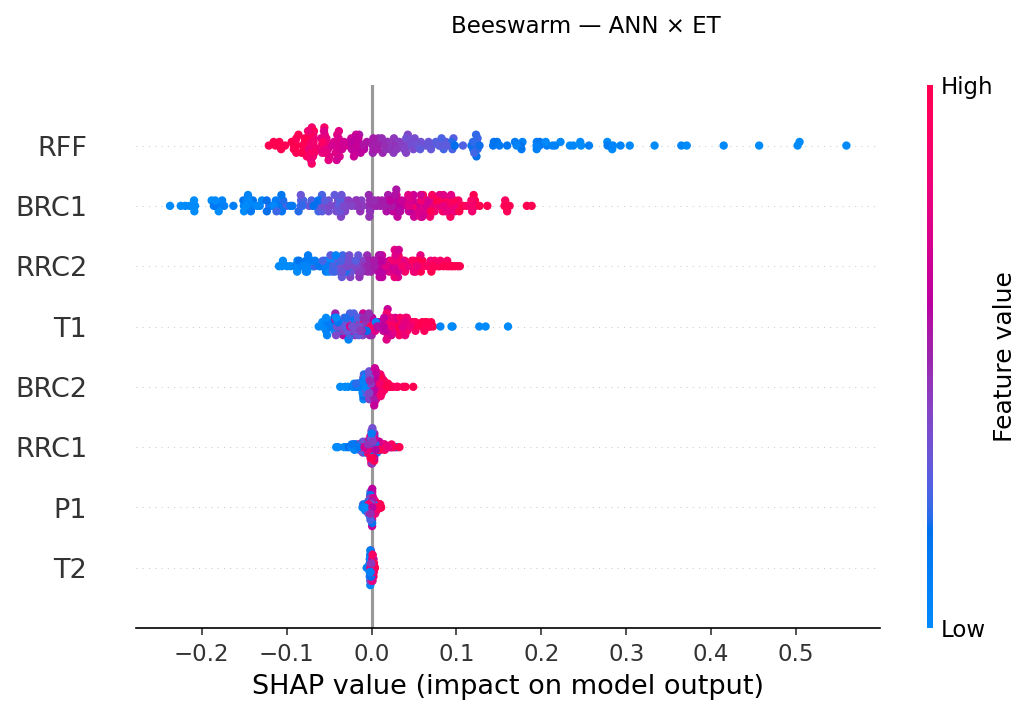

Beeswarm — XGBoost / ET


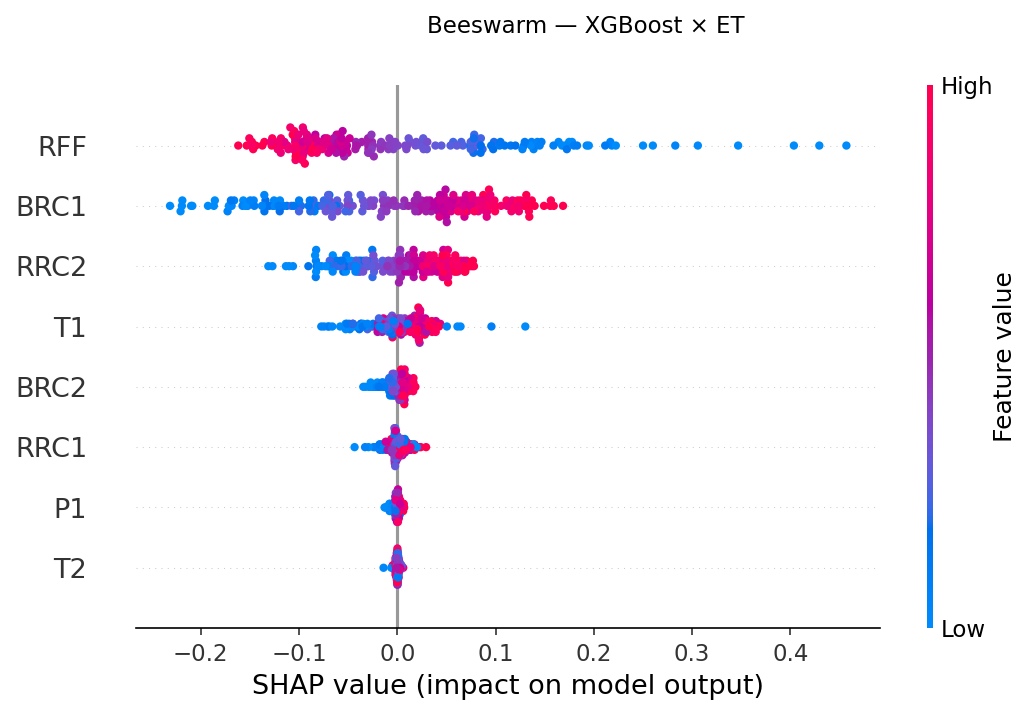


Feature: T1  |  Output: ET  |  frac_interacao: 0.832
Beeswarm — ANN / ET


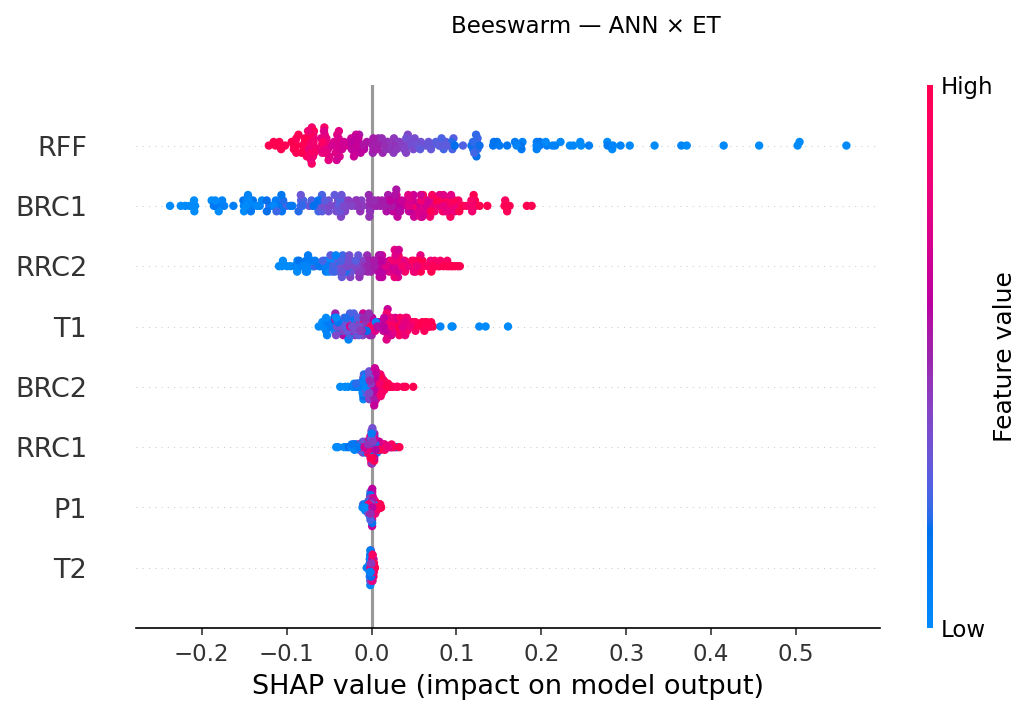

Beeswarm — XGBoost / ET


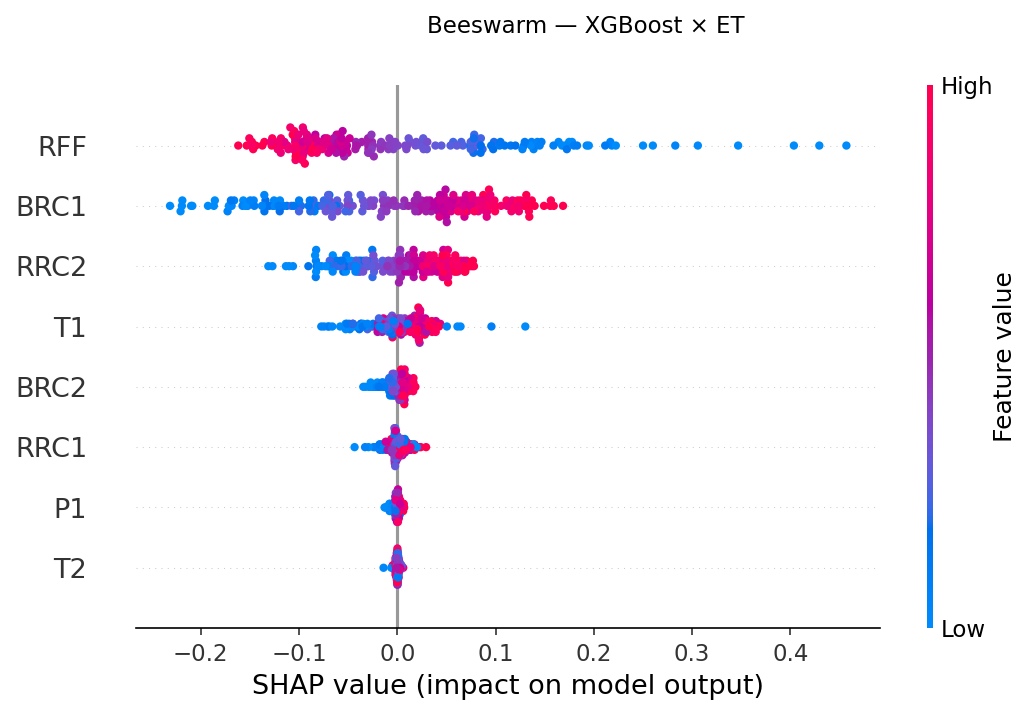


Feature: RRC2  |  Output: ET  |  frac_interacao: 0.315
Beeswarm — ANN / ET


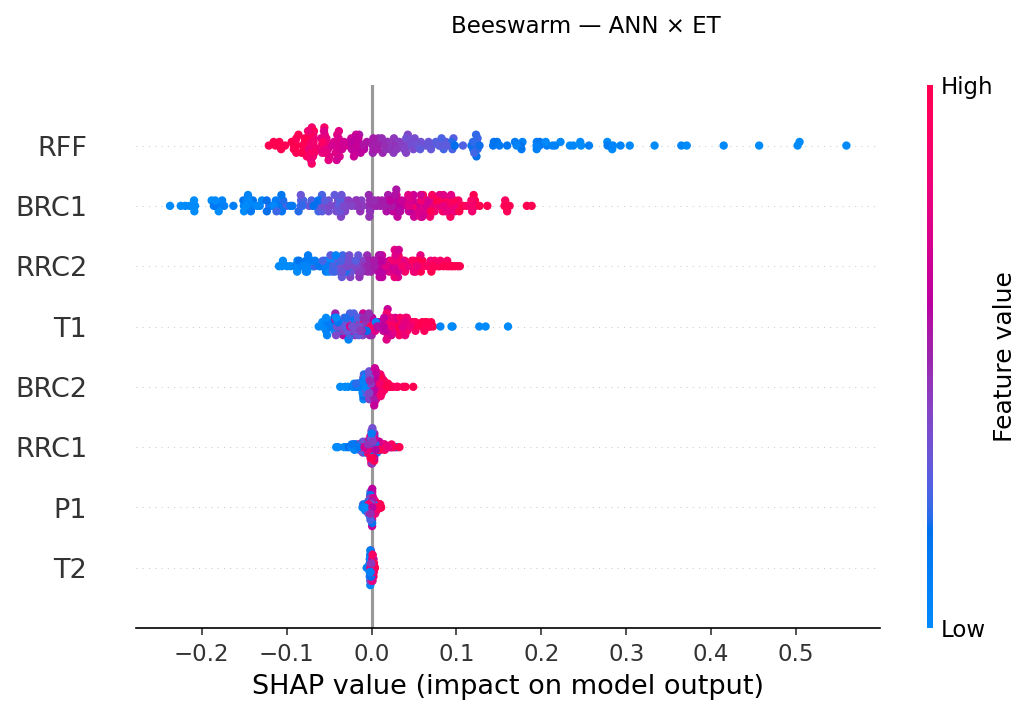

Beeswarm — XGBoost / ET


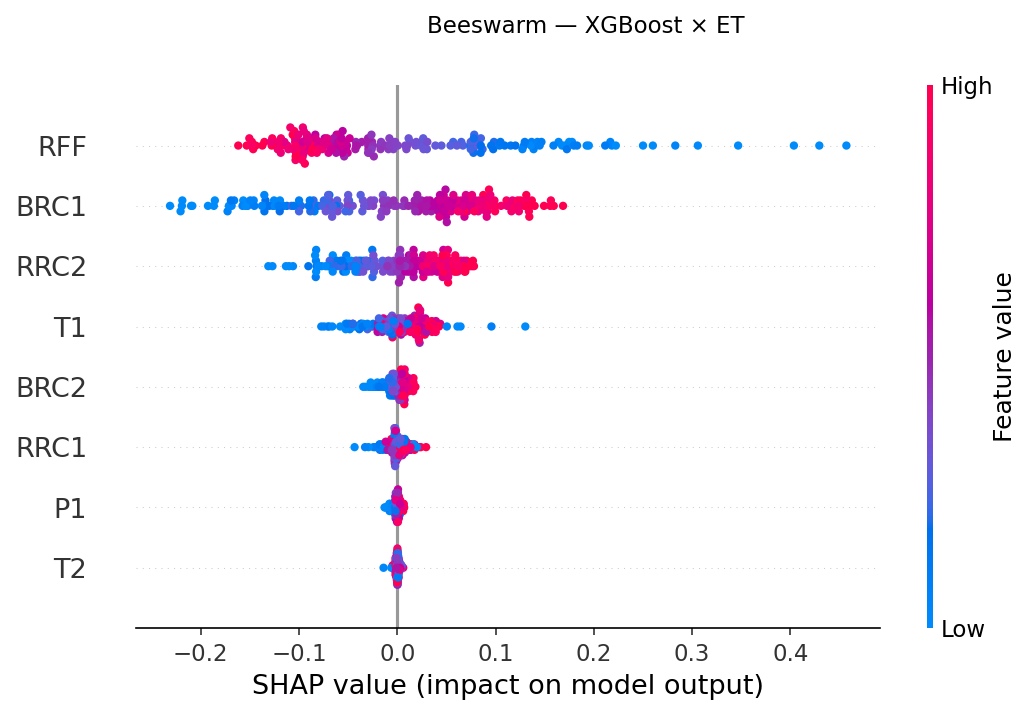


Feature: RRC1  |  Output: M_CH3OH  |  frac_interacao: 0.338
Beeswarm — ANN / M_CH3OH


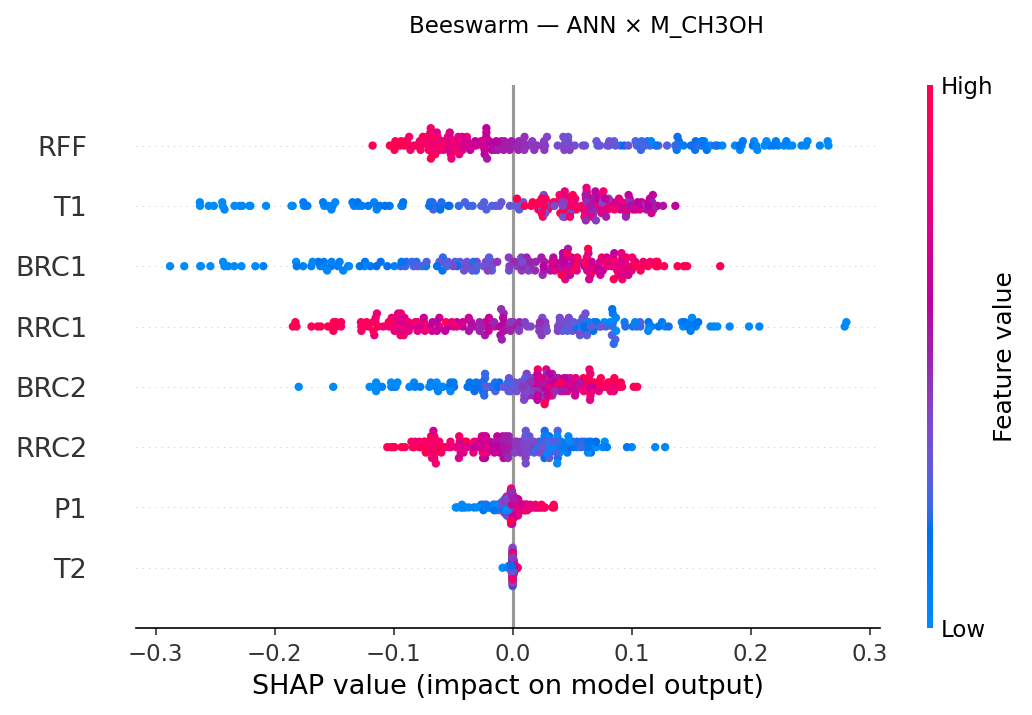

Beeswarm — XGBoost / M_CH3OH


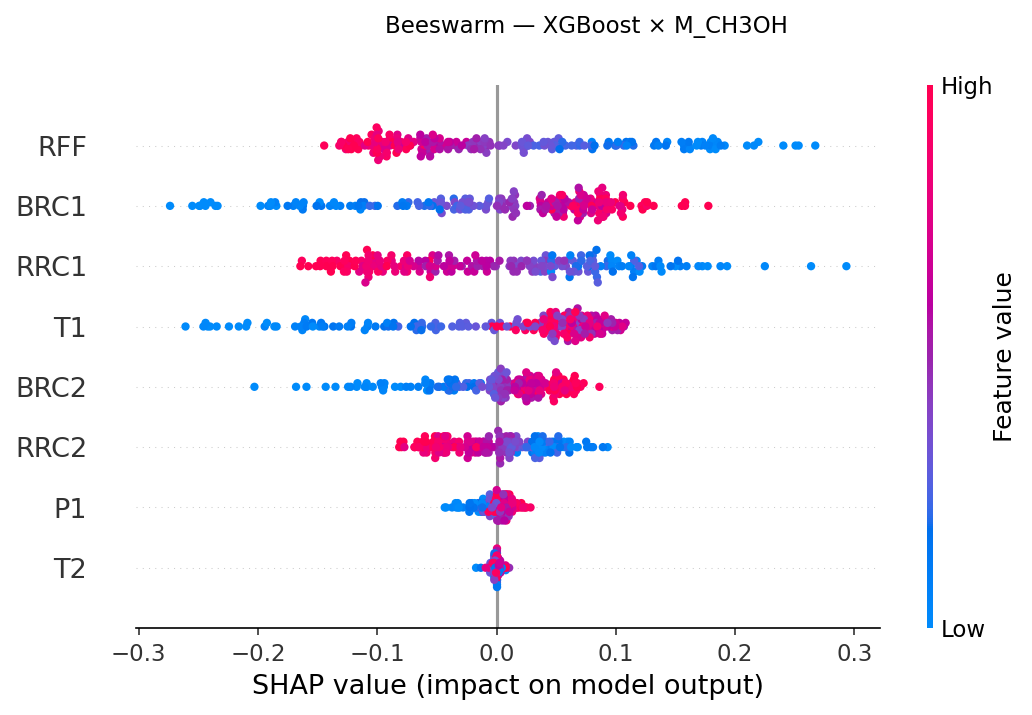


Feature: T1  |  Output: x_CH3OH  |  frac_interacao: 0.887
Beeswarm — ANN / x_CH3OH


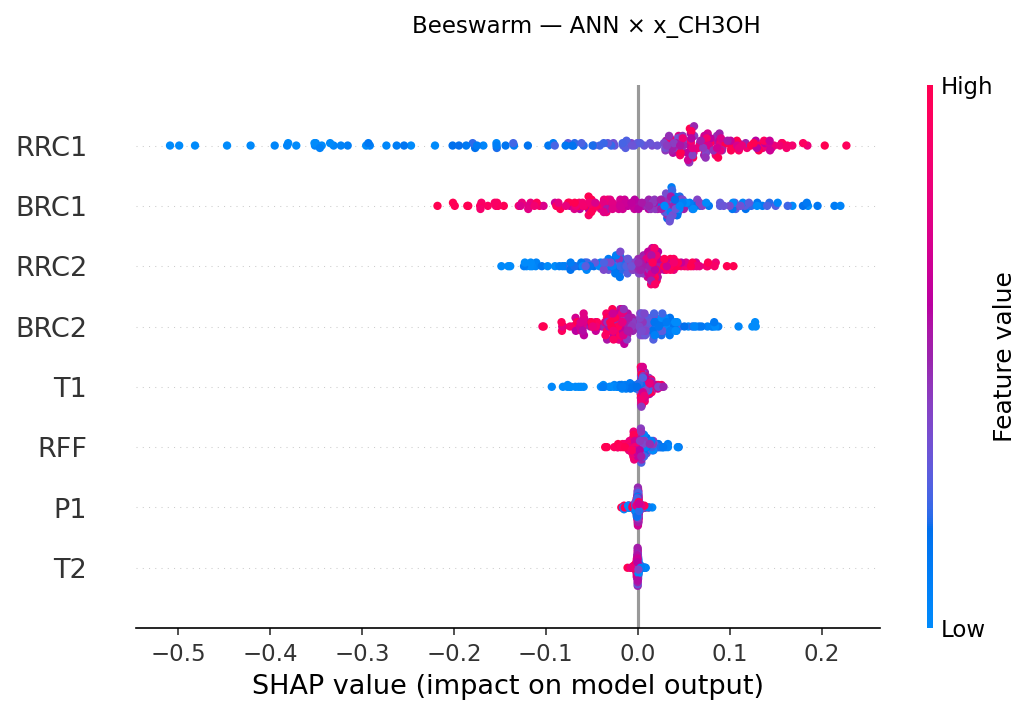

Beeswarm — XGBoost / x_CH3OH


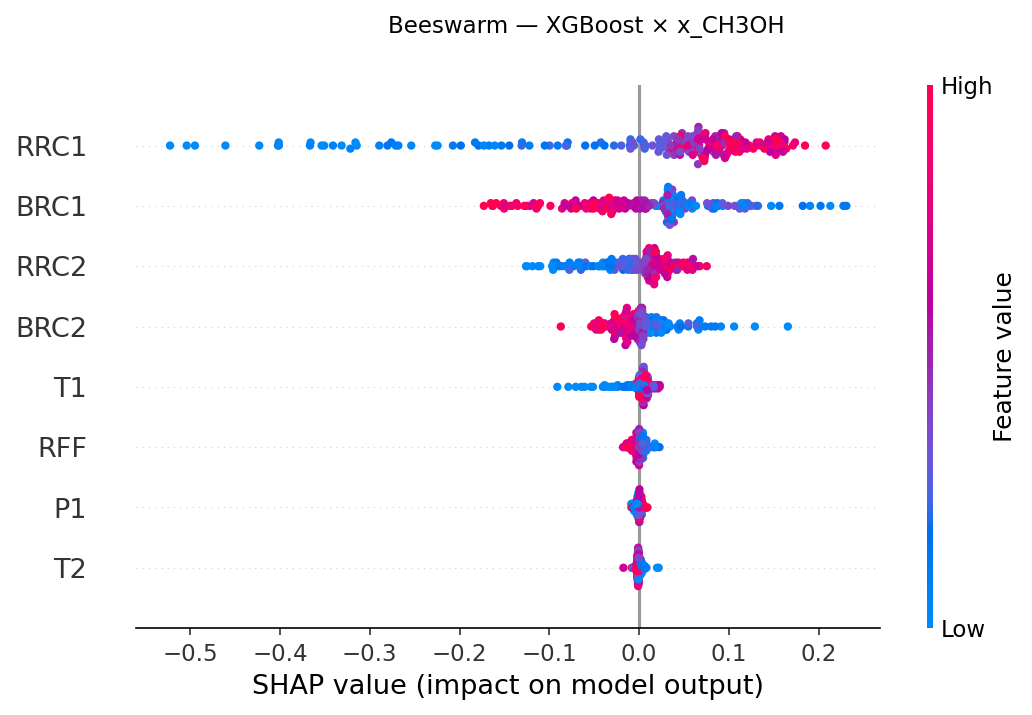


Feature: BRC2  |  Output: x_CH3OH  |  frac_interacao: 0.720
Beeswarm — ANN / x_CH3OH


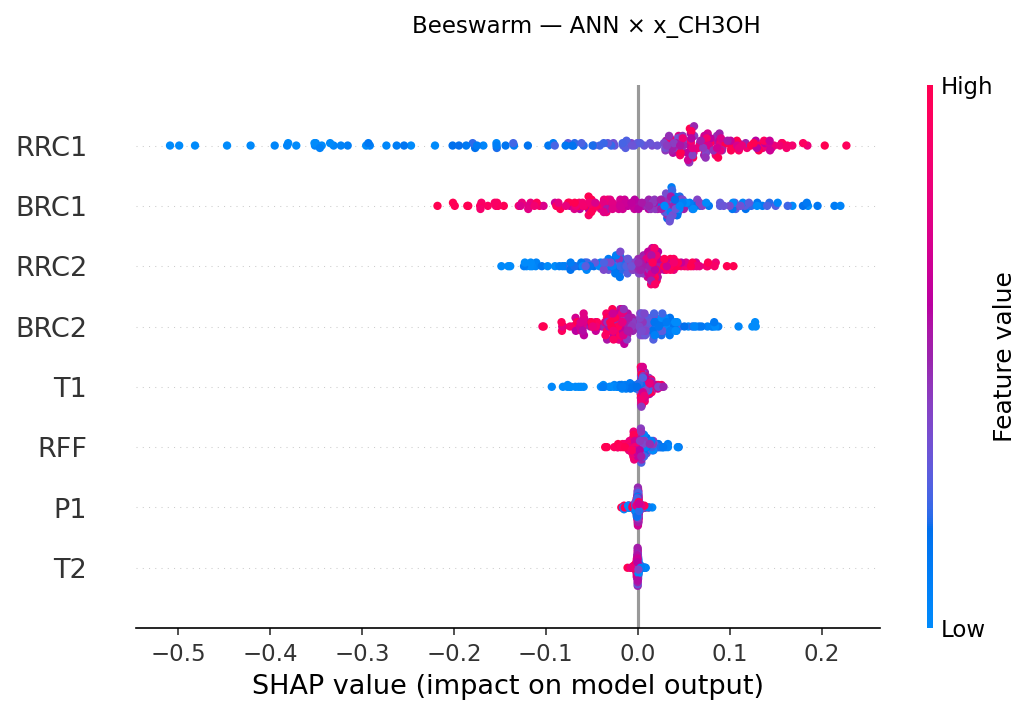

Beeswarm — XGBoost / x_CH3OH


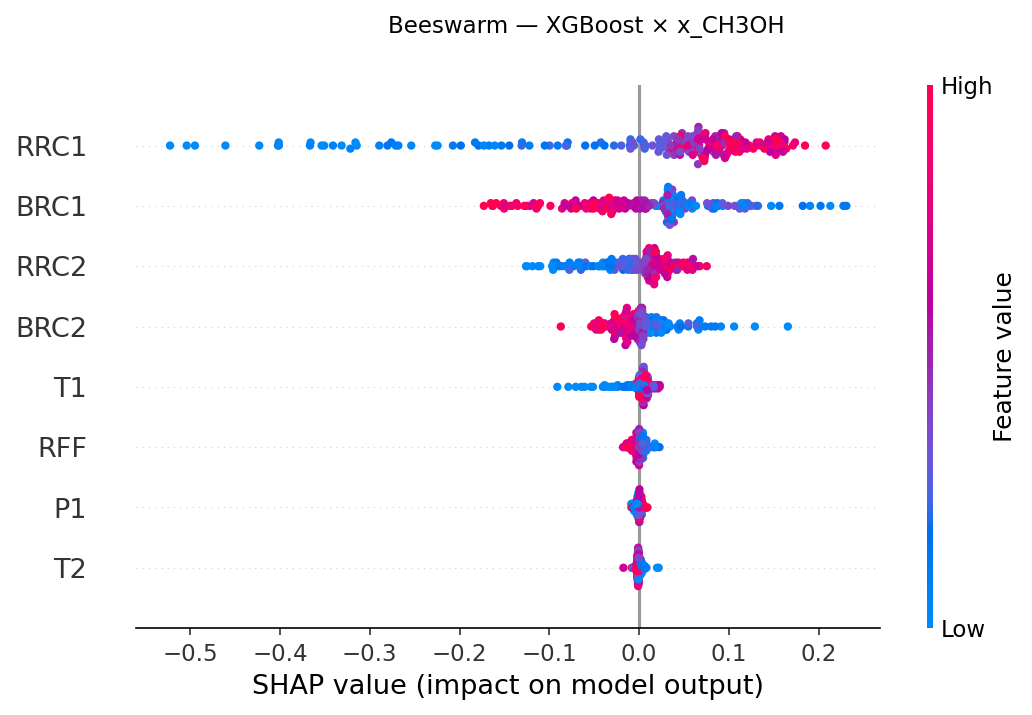


Feature: RRC2  |  Output: x_CH3OH  |  frac_interacao: 0.640
Beeswarm — ANN / x_CH3OH


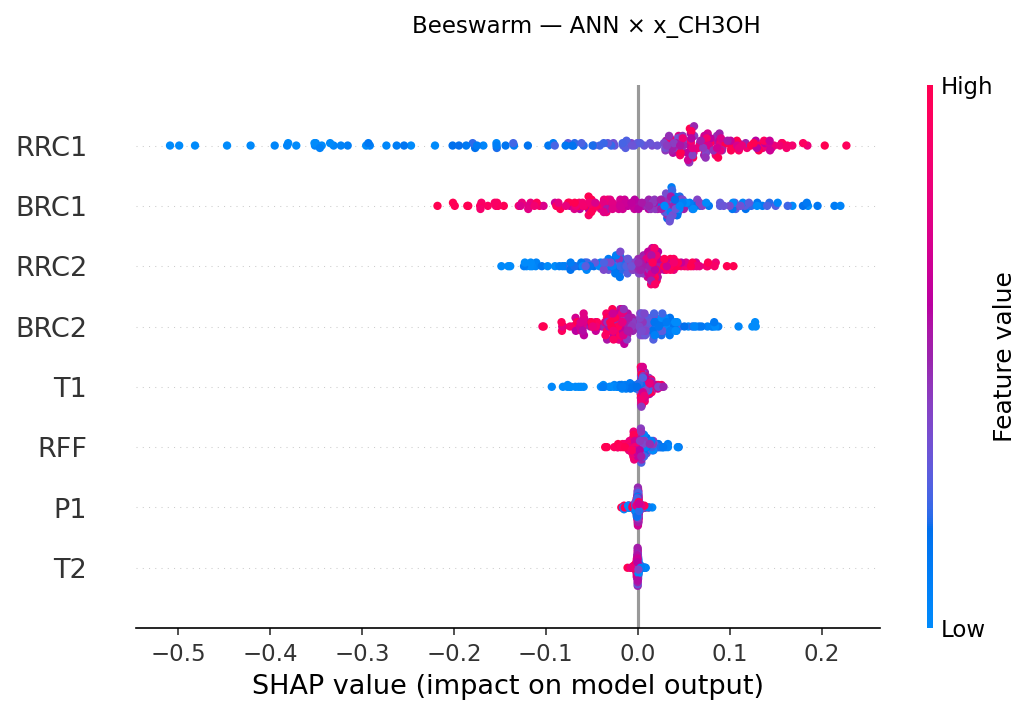

Beeswarm — XGBoost / x_CH3OH


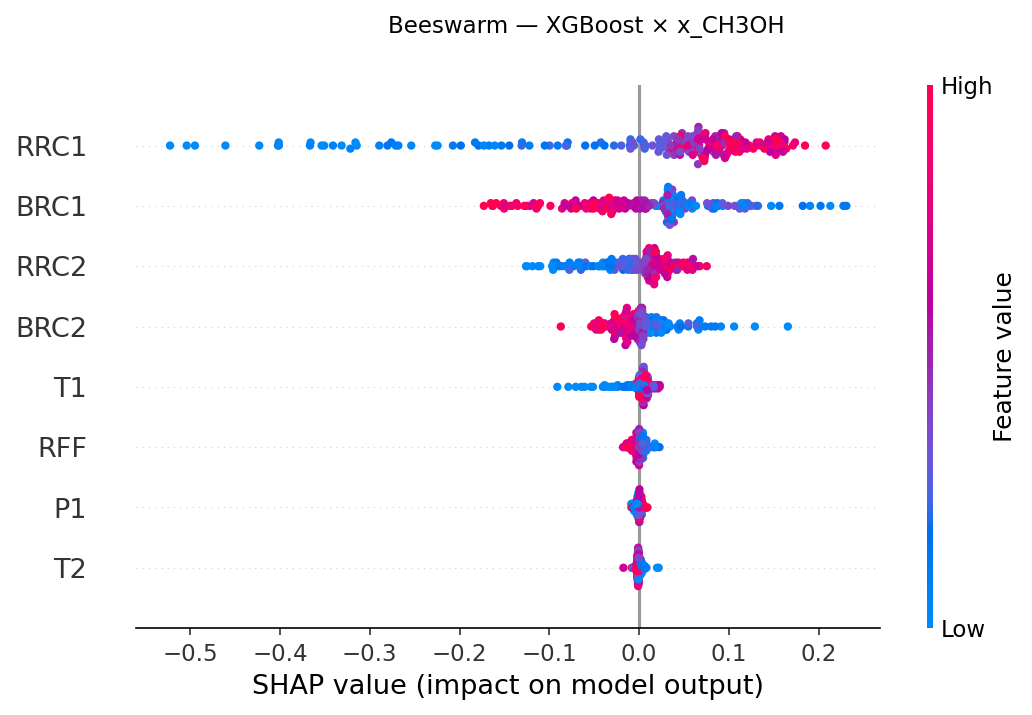


Feature: BRC1  |  Output: x_CH3OH  |  frac_interacao: 0.629
Beeswarm — ANN / x_CH3OH


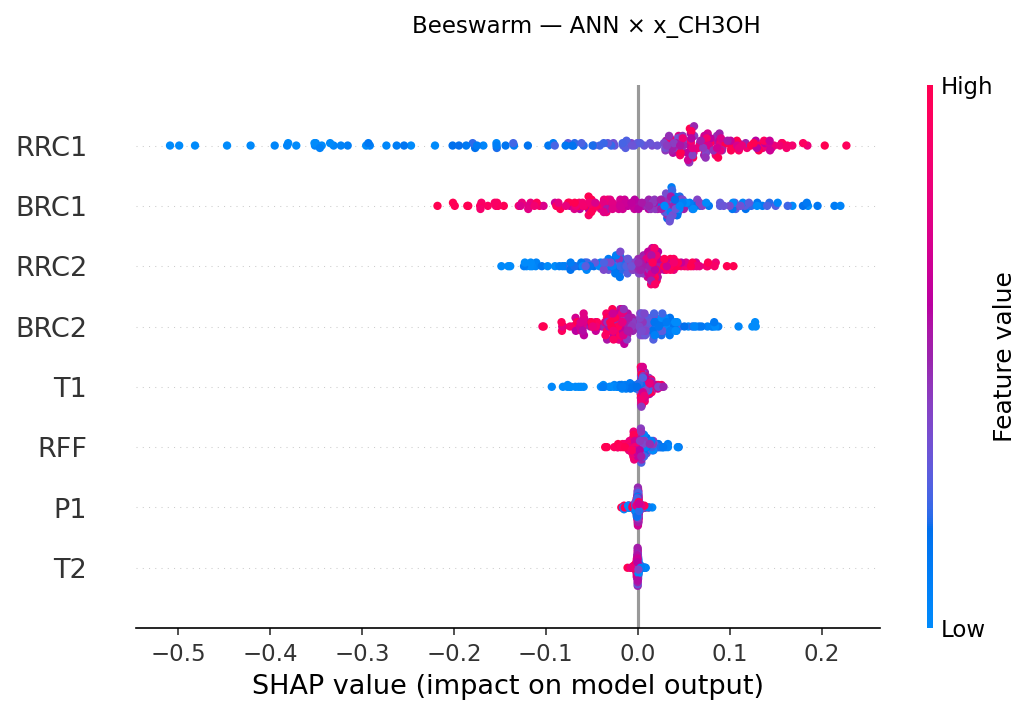

Beeswarm — XGBoost / x_CH3OH


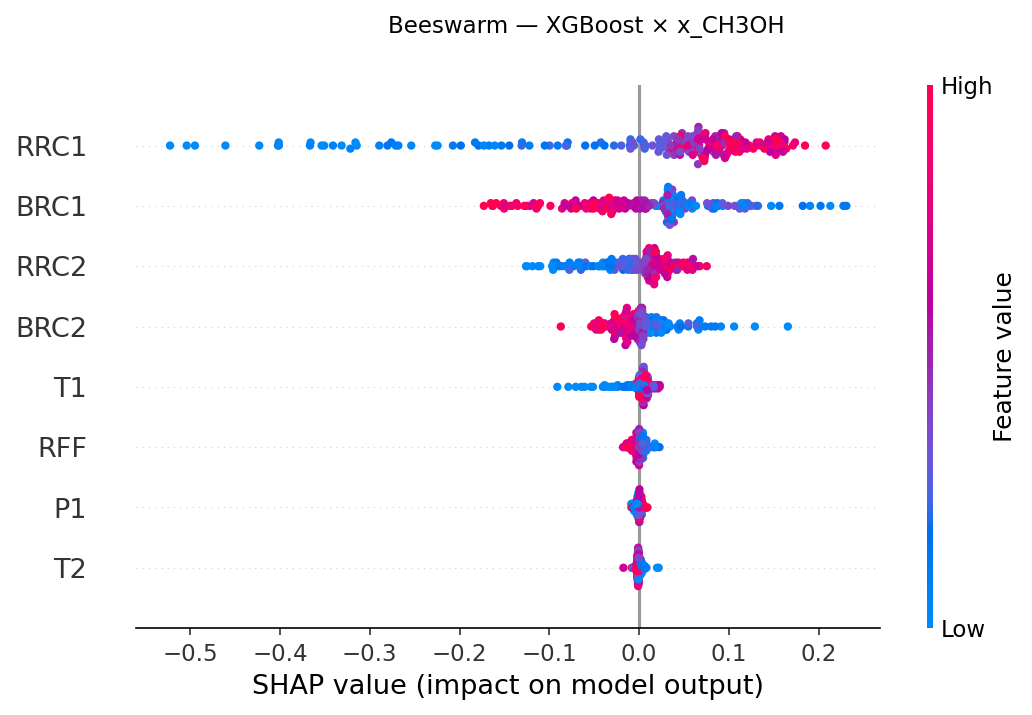


Feature: RRC1  |  Output: x_CH3OH  |  frac_interacao: 0.303
Beeswarm — ANN / x_CH3OH


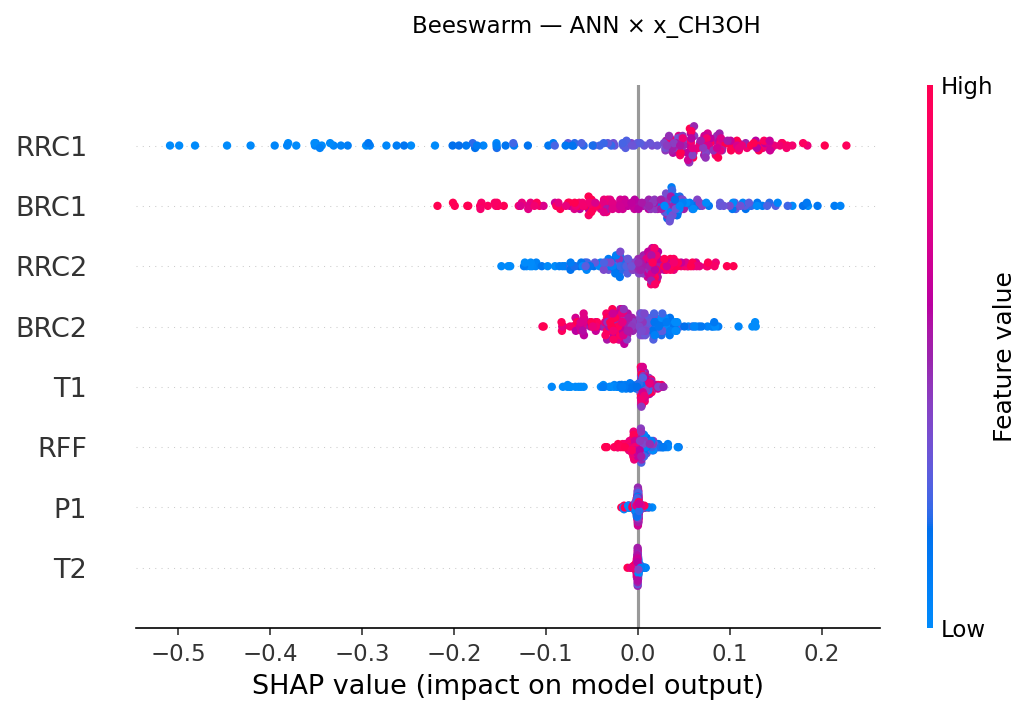

Beeswarm — XGBoost / x_CH3OH


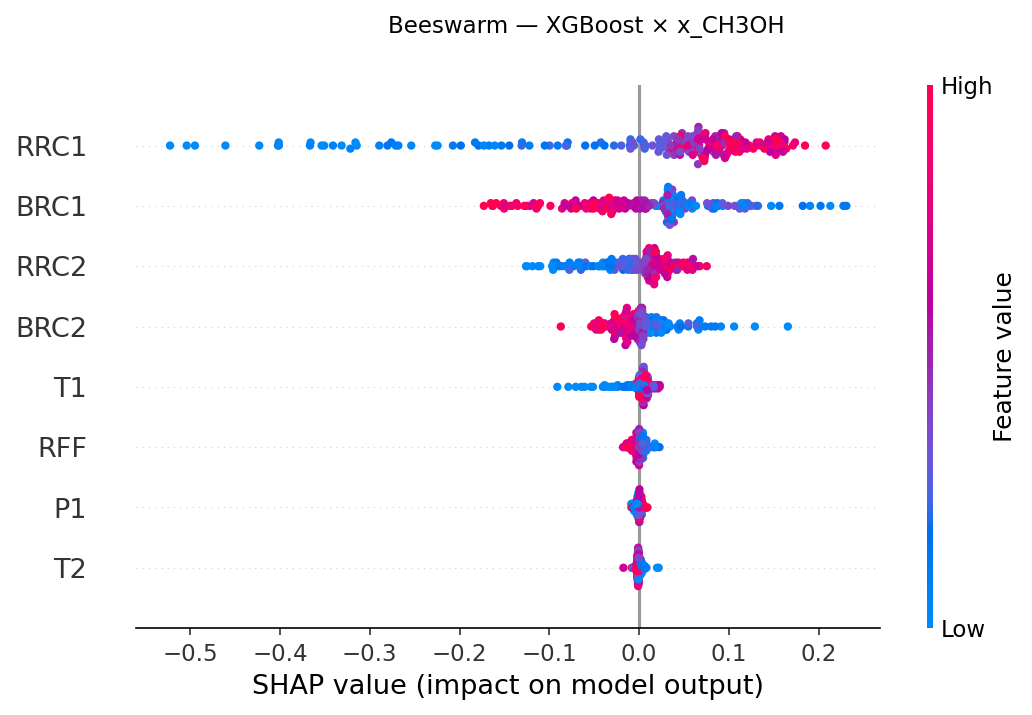

In [7]:
for _, row in altas.iterrows():
    output  = row['output']
    feature = row['feature']
    frac    = row['frac_interacao']

    print(f'\n{"="*62}')
    print(f'Feature: {feature}  |  Output: {output}  |  frac_interacao: {frac:.3f}')
    print(f'{"="*62}')

    for modelo in MODELOS_EXIBIR:
        fname = BEESWARM_DIR / f'3.1_beeswarm_{modelo}_{output}.png'
        if fname.exists():
            print(f'Beeswarm — {modelo} / {output}')
            display(Image(str(fname), width=680))
        else:
            print(f'  [nao encontrado: {fname}]')

In [8]:
# Tabela cruzada: padrao_beeswarm a preencher após inspeção visual das imagens acima.
# Valores válidos: 'monotônico', 'cluster', 'disperso'
PADROES = {
    # (output, feature): padrao — baseado em inspeção visual dos beeswarms exibidos acima
    ('ET',      'RRC1'):    'disperso',
    ('ET',      'T1'):      'disperso',
    ('ET',      'RRC2'):    'disperso',
    ('M_CH3OH', 'RRC1'):    'disperso',
    ('x_CH3OH', 'BRC1'):    'cluster',
    ('x_CH3OH', 'RRC2'):    'cluster',
    ('x_CH3OH', 'BRC2'):    'cluster',
    ('x_CH3OH', 'RRC1'):    'disperso',
}

tabela = altas.rename(columns={'frac_interacao': 'frac_interacao_sobol'}).copy()
tabela['padrao_beeswarm'] = tabela.apply(
    lambda r: PADROES.get((r['output'], r['feature']), '—'), axis=1
)

print('Tabela cruzada Sobol × SHAP:')
print(tabela.to_string(index=False))

Tabela cruzada Sobol × SHAP:
 output feature  frac_interacao_sobol padrao_beeswarm
     ET    RRC1              1.000000        disperso
     ET      T1              0.831669        disperso
     ET    RRC2              0.314883        disperso
M_CH3OH    RRC1              0.338434        disperso
x_CH3OH      T1              0.886934               —
x_CH3OH    BRC2              0.719822         cluster
x_CH3OH    RRC2              0.640362         cluster
x_CH3OH    BRC1              0.628904         cluster
x_CH3OH    RRC1              0.303452        disperso


## Seção 5 — Narrativa

In [9]:
# Coleta de estatísticas para a narrativa
n_altas         = len(altas)
n_excluidas_nar = df['frac_interacao'].isna().sum()
outputs_c_altas = sorted(altas['output'].unique())

def fmt_feature_list(output):
    sub = altas[altas['output'] == output]
    if sub.empty:
        return 'nenhuma'
    return ', '.join(
        f"{r['feature']} ({r['frac_interacao']:.2f})"
        for _, r in sub.iterrows()
    )

narrativa = f"""# 4.4 — Cruzamento Sobol × SHAP: Análise de Interações

## Configuração

- Limiar de interação: `frac_interacao > {LIMIAR}` (D-E4-07)
- ST_MIN = {ST_MIN}: {n_excluidas_nar} pares excluídos por importância desprezível
- Pares com frac_interacao > {LIMIAR} (elegíveis): {n_altas} de {24 - n_excluidas_nar}
- Outputs com alta interação: {', '.join(outputs_c_altas)}

---

## Por output

### ET (consumo de energia)

Features com frac_interacao > {LIMIAR}: {fmt_feature_list('ET')}

A energia é dominada por `RFF` e `BRC1` (maiores S_Ti), com efeito majoritariamente aditivo.
`T1` e `RRC1` têm S_Ti baixos para ET, mas S1 próximo de zero — o pouco efeito que exercem
sobre a energia se dá quase inteiramente através de interações com outras variáveis.
`RRC2` apresenta frac_interacao ≈ 0.31: acoplamento esperado com `BRC2` no circuito energético
da coluna 2 (refluxo e boil-up determinam conjuntamente o reboiler duty).

### M_CH3OH (vazão de metanol)

Features com frac_interacao > {LIMIAR}: {fmt_feature_list('M_CH3OH')}

`RRC1` é o único par elegível com interação relevante. Embora seu S_Ti seja significativo (≈0.24),
cerca de 34% desse efeito ocorre via interação — provavelmente com `BRC1`, que controla a mesma
coluna. O beeswarm de ANN/XGBoost para RRC1/M_CH3OH exibe maior dispersão vertical do que T2 ou P1,
confirmando que o impacto de RRC1 depende do estado das demais variáveis.

### x_CH3OH (pureza do metanol)

Features com frac_interacao > {LIMIAR}: {fmt_feature_list('x_CH3OH')}

A pureza é o output com maior carga de interação. `BRC1`, `RRC2` e `BRC2` têm S_Ti relevantes
mas S_i pequenos — o que indica que essas variáveis afetam a pureza principalmente via
acoplamento com outras features, não pelo efeito direto individual.

Os acoplamentos RRC1–BRC1 (coluna 1) e RRC2–BRC2 (coluna 2) são fisicamente coerentes:
a pureza do destilado depende do balanço entre razão de refluxo e boil-up em cada coluna,
e não do valor de cada variável isoladamente.

---

## Acoplamentos identificados

| Par | Output | Mecanismo provável |
|-----|--------|--------------------|
| RRC1–BRC1 | M_CH3OH, x_CH3OH | Refluxo e boil-up da coluna 1 determinam conjuntamente o balanço da separação primária |
| RRC2–BRC2 | x_CH3OH | Refluxo e boil-up da coluna 2 controlam a pureza final; o efeito de um depende do outro |
| RRC2–outros | ET | Operação da coluna 2 interage com o circuito global no consumo energético |

---

## Consistência com SHAP

Features com alta frac_interacao (BRC1, RRC2, BRC2 para x_CH3OH) exibem maior dispersão
vertical nos beeswarms de ANN e XGBoost — sinal de que o SHAP value para um mesmo valor
da feature varia conforme o contexto das demais. Isso é coerente com o que o índice
S_Ti − S_i quantifica: a importância que só emerge combinada com outras variáveis.
"""

with open('4.4_cruzamento_sobol_shap.md', 'w', encoding='utf-8') as f:
    f.write(narrativa)

print('Salvo: 4.4_cruzamento_sobol_shap.md')
print(narrativa)

Salvo: 4.4_cruzamento_sobol_shap.md
# 4.4 — Cruzamento Sobol × SHAP: Análise de Interações

## Configuração

- Limiar de interação: `frac_interacao > 0.3` (D-E4-07)
- ST_MIN = 0.02: 8 pares excluídos por importância desprezível
- Pares com frac_interacao > 0.3 (elegíveis): 9 de 16
- Outputs com alta interação: ET, M_CH3OH, x_CH3OH

---

## Por output

### ET (consumo de energia)

Features com frac_interacao > 0.3: RRC1 (1.00), T1 (0.83), RRC2 (0.31)

A energia é dominada por `RFF` e `BRC1` (maiores S_Ti), com efeito majoritariamente aditivo.
`T1` e `RRC1` têm S_Ti baixos para ET, mas S1 próximo de zero — o pouco efeito que exercem
sobre a energia se dá quase inteiramente através de interações com outras variáveis.
`RRC2` apresenta frac_interacao ≈ 0.31: acoplamento esperado com `BRC2` no circuito energético
da coluna 2 (refluxo e boil-up determinam conjuntamente o reboiler duty).

### M_CH3OH (vazão de metanol)

Features com frac_interacao > 0.3: RRC1 (0.34)

`RRC1` é o único par elegí

## Validação final

In [10]:
import os

artefatos = [
    '4.4_interacoes_barplot_ET.png',
    '4.4_interacoes_barplot_M.png',
    '4.4_interacoes_barplot_x.png',
    '4.4_cruzamento_sobol_shap.md',
]

ok = True
for f in artefatos:
    existe = os.path.exists(f)
    status = 'OK' if existe else 'AUSENTE'
    print(f'  [{status}] {f}')
    ok = ok and existe

# frac_interacao ∈ [0,1] para elegíveis
elegivel = df[df['frac_interacao'].notna()]
assert (elegivel['frac_interacao'] >= 0).all() and (elegivel['frac_interacao'] <= 1).all()
print(f'  [OK] frac_interacao ∈ [0, 1] para {len(elegivel)} pares elegíveis')

# narrativa com ao menos 3 seções de output
n_secoes_narrativa = narrativa.count('###')
assert n_secoes_narrativa >= 3
print(f'  [OK] 4.4_cruzamento_sobol_shap.md com {n_secoes_narrativa} seções de output')

print('\nEtapa 4.4 concluída.' if ok else '\nAtencao: algum artefato ausente.')

  [OK] 4.4_interacoes_barplot_ET.png
  [OK] 4.4_interacoes_barplot_M.png
  [OK] 4.4_interacoes_barplot_x.png
  [OK] 4.4_cruzamento_sobol_shap.md
  [OK] frac_interacao ∈ [0, 1] para 16 pares elegíveis
  [OK] 4.4_cruzamento_sobol_shap.md com 3 seções de output

Etapa 4.4 concluída.
